# Exploratory Data Analysis
## ChatGPT Use and Academic Performance Among Medical Students
**Omdurman Islamic University, Sudan – 2025**

This notebook documents the exploratory analysis phase prior to formal statistical testing in SPSS.
It covers data quality checks, distribution review, and initial pattern identification across the key variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

df = pd.read_excel("../1_data/cleaned/cleaned_data.xlsx")
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)


Dataset: 295 rows × 38 columns


,Gender,Age,Year_in_Medical_School,Current_Residency,Family_Income_Level,Financial_Constraints_for_ChatGPT,Financial_Challenges_Internet_Study,University_Guidance_on_ChatGPT,Lecturers_Encouragement,Institution_Training_on_AI,...,Perception_Exam_Prep_num,Perception_Accuracy_num,Perception_Verification_num,Perception_Confidence_num,Perception_Time_Saving_num,Perception_Study_Encouragement_num,Perception_Replacement_num,Perception_Enjoyment_num,Perception_Recommendation_num,Perceptions_Score
0,Female,Between 20 and 24 years 20 24,Fifth year,Omdurman,Low,Occasionally,Yes,No official guidance,Sometimes,No,...,4,3,5,3,4,4,4,5,5,4.1
1,Female,Between 20 and 24 years 20 24,Fifth year,Khartoum,Moderate,Rarely,No,No official guidance,Sometimes,No,...,3,3,3,3,3,3,3,3,3,3.0
2,Male,Between 20 and 24 years 20 24,Fifth year,Omdurman,Moderate,Never,No,No official guidance,Rarely,No,...,3,2,4,2,2,2,2,2,2,2.4


## 1. Data Quality

In [2]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No missing values in the cleaned dataset.")
else:
    print("Columns with missing values:")
    print(missing)


No missing values in the cleaned dataset.


In [3]:
# Column data types
df.dtypes.value_counts()

object     27
int64      10
float64     1
Name: count, dtype: int64

## 2. Demographic Profile

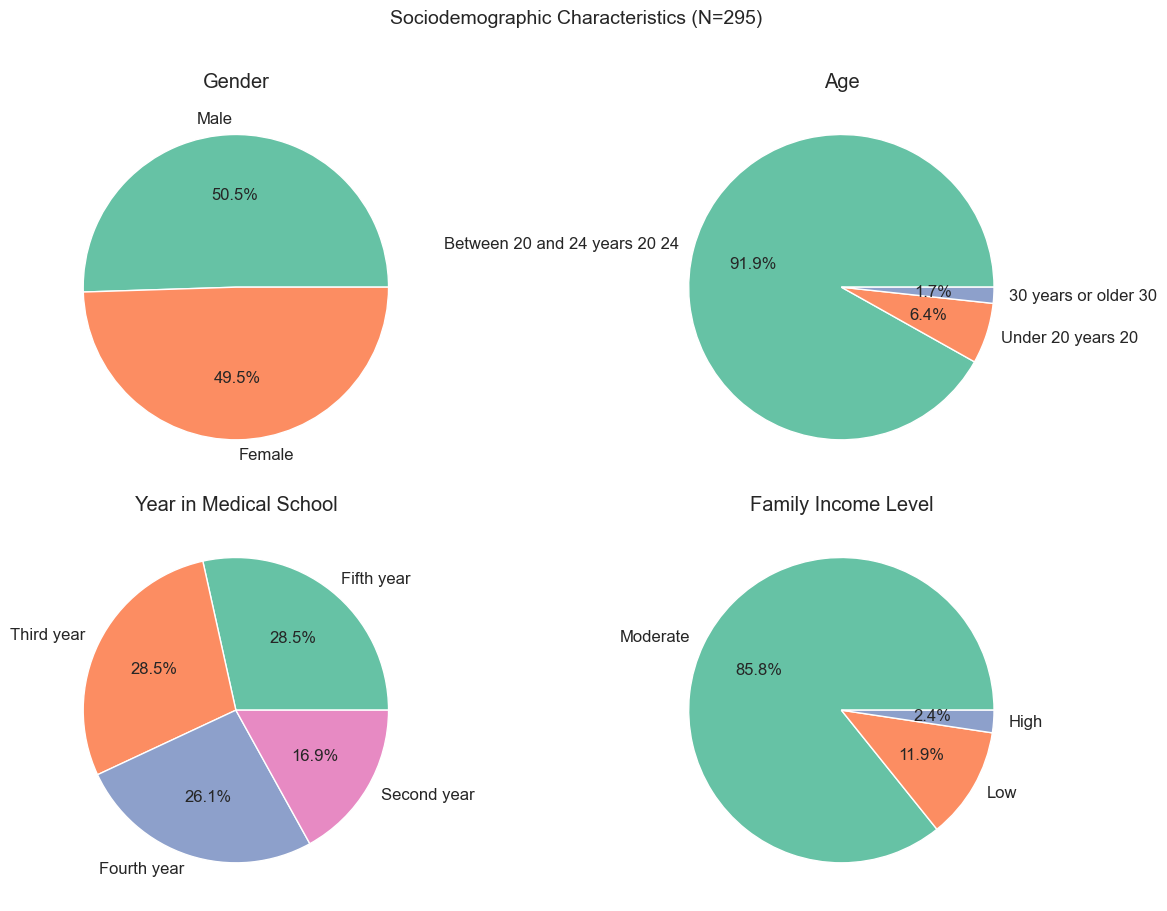

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Sociodemographic Characteristics (N=295)", fontsize=14, y=1.01)

demo_cols = {
    "Gender": axes[0, 0],
    "Age": axes[0, 1],
    "Year_in_Medical_School": axes[1, 0],
    "Family_Income_Level": axes[1, 1],
}

palette = sns.color_palette("Set2")

for col, ax in demo_cols.items():
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=palette)
    ax.set_title(col.replace("_", " "))

plt.tight_layout()
plt.show()


**Observations:**
- Near-equal gender split (~50/50)
- Majority aged 20–24 (91.9%), consistent with medical school demographics
- Academic year distribution is relatively balanced across 2nd–5th year
- Most students report moderate family income (85.7%)


## 3. ChatGPT Usage Patterns

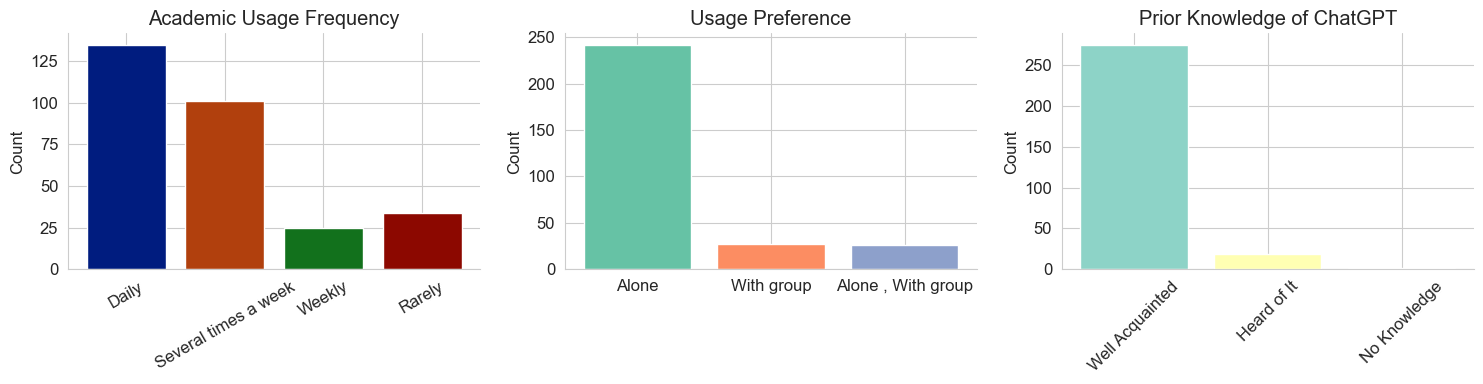

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Usage frequency
freq_order = ["Daily", "Several times a week", "Weekly", "Rarely"]
freq_counts = df["ChatGPT_Academic_Frequency"].value_counts().reindex(freq_order)
axes[0].bar(freq_counts.index, freq_counts.values, color=sns.color_palette("dark"))
axes[0].set_title("Academic Usage Frequency")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Usage preference
pref_counts = df["ChatGPT_Usage_Preference"].value_counts()
axes[1].bar(pref_counts.index, pref_counts.values, color=sns.color_palette("Set2"))
axes[1].set_title("Usage Preference")
axes[1].set_ylabel("Count")

# Prior knowledge
know_counts = df["Prior_Knowledge_of_ChatGPT"].value_counts()

axes[2].bar(know_counts.index, know_counts.values, color=sns.color_palette("Set3"))
axes[2].set_title("Prior Knowledge of ChatGPT")
axes[2].set_ylabel("Count")

short_labels_map = {
    "Yes, I am well acquainted with it": "Well Acquainted",
    "I have only heard about it": "Heard of It",
    "No, I do not know anything about it": "No Knowledge"
}
new_labels = [short_labels_map.get(label, label) for label in know_counts.index]

axes[2].set_xticks(range(len(new_labels)))
axes[2].set_xticklabels(new_labels, rotation=45)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [7]:
# Proportion of frequent users (daily + several times/week)
frequent_mask = df["ChatGPT_Academic_Frequency"].isin(["Daily", "Several times a week"])
n_frequent = frequent_mask.sum()
pct_frequent = (n_frequent / len(df)) * 100
print(f"Frequent users (daily or several times/week): {n_frequent} / {len(df)} ({pct_frequent:.1f}%)")


Frequent users (daily or several times/week): 236 / 295 (80.0%)


## 4. Perceptions Scale — Distributions and Reliability

In [8]:
perception_cols = [c for c in df.columns if c.startswith("Perception_") and not c.endswith("_num") and "Score" not in c]
numeric_perception_cols = [c for c in df.columns if "Perception" in c and "_num" in c]

# Compute composite score if not already in data
if "Perceptions_Score" not in df.columns:
    for col in numeric_perception_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df["Perceptions_Score"] = df[numeric_perception_cols].mean(axis=1)

print("Perceptions Score — summary statistics:")
print(df["Perceptions_Score"].describe().round(3))


Perceptions Score — summary statistics:
count    295.000
mean       3.442
std        0.879
min        1.000
25%        3.000
50%        3.600
75%        4.000
max        5.000
Name: Perceptions_Score, dtype: float64


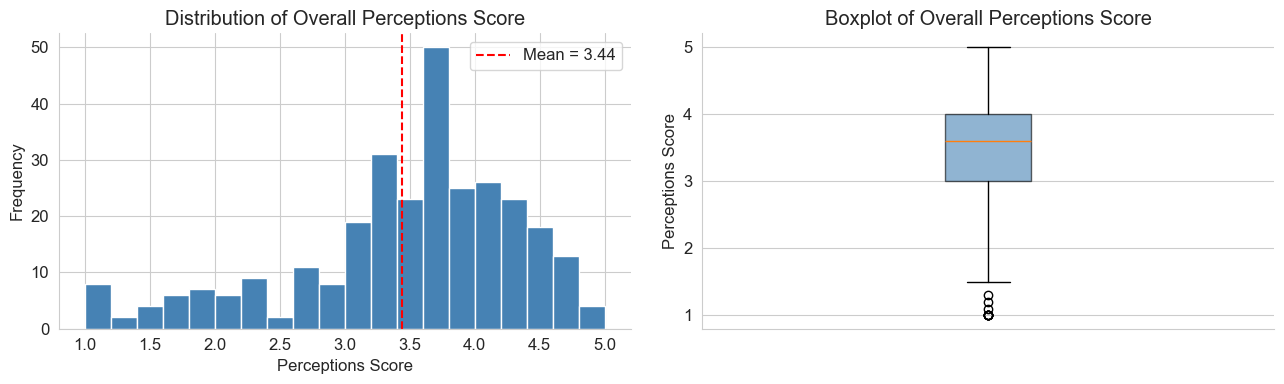

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of composite score
axes[0].hist(df["Perceptions_Score"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(df["Perceptions_Score"].mean(), color="red", linestyle="--", label=f'Mean = {df["Perceptions_Score"].mean():.2f}')
axes[0].set_xlabel("Perceptions Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Overall Perceptions Score")
axes[0].legend()

# Boxplot of composite score
axes[1].boxplot(df["Perceptions_Score"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Perceptions Score")
axes[1].set_title("Boxplot of Overall Perceptions Score")
axes[1].set_xticks([])

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


**Note on reliability:**
Cronbach's Alpha = 0.919 was computed in SPSS for the 10-item scale. This indicates excellent internal consistency; all items are reliably measuring the same underlying construct (perceived academic benefit from ChatGPT).


## 5. Key Relationships — Preliminary Patterns

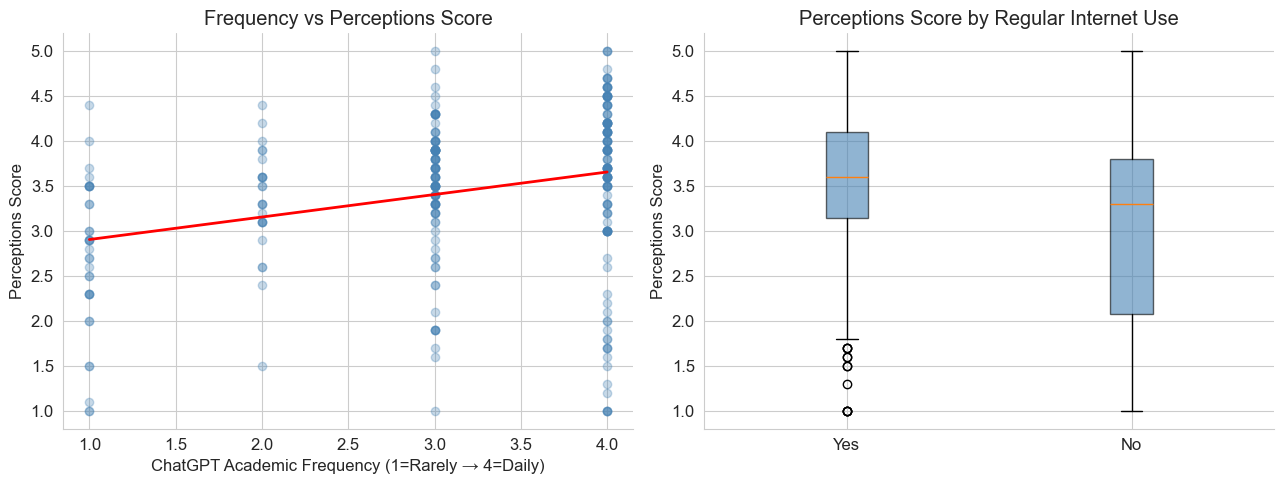

Pearson r (frequency vs perceptions score): 0.283


In [10]:
# Frequency mapping for numeric use
freq_map = {"Rarely": 1, "Weekly": 2, "Several times a week": 3, "Daily": 4}
df["Freq_num"] = df["ChatGPT_Academic_Frequency"].map(freq_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: frequency vs perceptions score
axes[0].scatter(df["Freq_num"], df["Perceptions_Score"], alpha=0.3, color="steelblue")
# Trend line
m, b = pd.Series(df["Freq_num"]).corr(pd.Series(df["Perceptions_Score"])), None
z = np.polyfit(df["Freq_num"].dropna(), df.loc[df["Freq_num"].notna(), "Perceptions_Score"], 1)
p = np.poly1d(z)
x_line = np.linspace(1, 4, 100)
axes[0].plot(x_line, p(x_line), color="red", linewidth=2)
axes[0].set_xlabel("ChatGPT Academic Frequency (1=Rarely → 4=Daily)")
axes[0].set_ylabel("Perceptions Score")
axes[0].set_title("Frequency vs Perceptions Score")

# Boxplot: perceptions score by internet use
internet_groups = [
    df.loc[df["Regular_Internet_Use_for_Study"] == val, "Perceptions_Score"].dropna().values
    for val in df["Regular_Internet_Use_for_Study"].unique()
]
labels_net = list(df["Regular_Internet_Use_for_Study"].unique())
axes[1].boxplot(internet_groups, labels=labels_net, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Perceptions Score")
axes[1].set_title("Perceptions Score by Regular Internet Use")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

r = df["Freq_num"].corr(df["Perceptions_Score"])
print(f"Pearson r (frequency vs perceptions score): {r:.3f}")


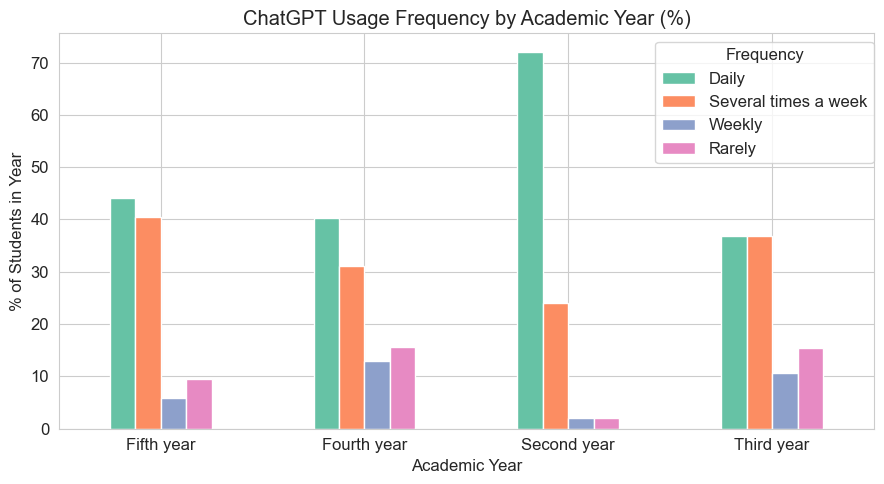


Observation: 2nd-year students show the highest proportion of daily users.


In [11]:
# Academic year vs usage frequency — crosstab
year_freq_ct = pd.crosstab(
    df["Year_in_Medical_School"],
    df["ChatGPT_Academic_Frequency"],
    normalize="index"
) * 100

year_freq_ct[["Daily", "Several times a week", "Weekly", "Rarely"]].plot(
    kind="bar", figsize=(9, 5), color=sns.color_palette("Set2", 4)
)
plt.title("ChatGPT Usage Frequency by Academic Year (%)")
plt.ylabel("% of Students in Year")
plt.xlabel("Academic Year")
plt.legend(title="Frequency", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nObservation: 2nd-year students show the highest proportion of daily users.")


## 6. Correlation Structure of Perceptions Scale

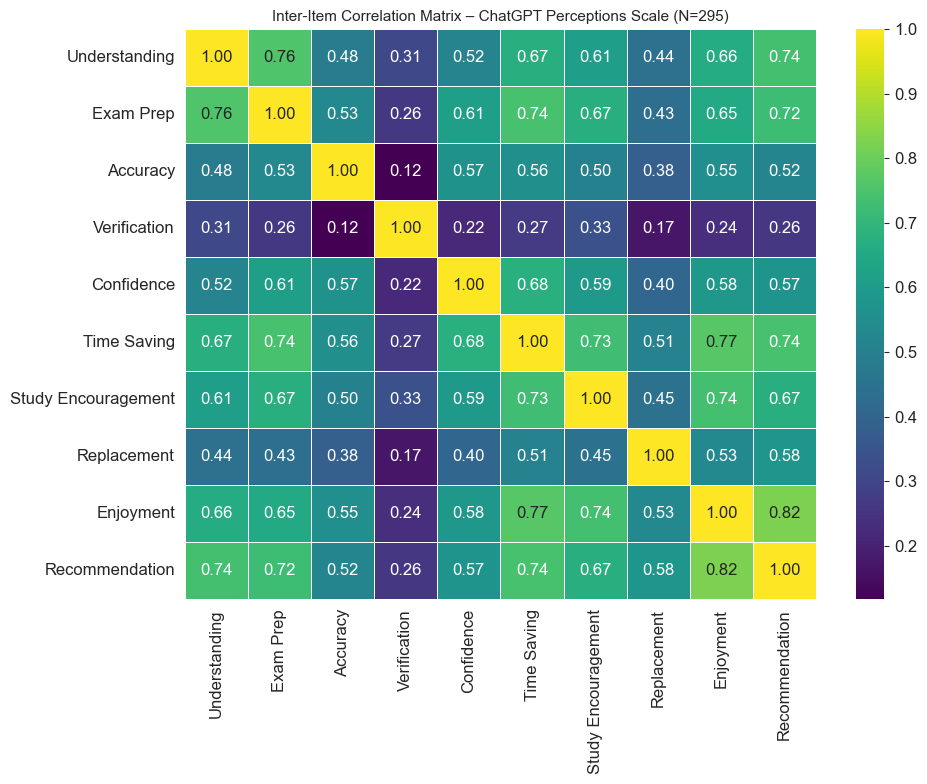

Lowest correlation: 0.117
Highest off-diagonal correlation: 0.824
All correlations positive and statistically significant (confirmed in SPSS, p < 0.05)


In [12]:
# Correlation matrix of the 10 perception items
if len(numeric_perception_cols) >= 10:
    for col in numeric_perception_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    corr_matrix = df[numeric_perception_cols].corr()
    short_labels = [
        "Understanding", "Exam Prep", "Accuracy", "Verification", "Confidence",
        "Time Saving", "Study Encouragement", "Replacement", "Enjoyment", "Recommendation"
    ]
    corr_matrix.index = short_labels[:len(corr_matrix)]
    corr_matrix.columns = short_labels[:len(corr_matrix)]

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
    import numpy as np
    mask_np = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis",
                linewidths=0.5, ax=ax)
    ax.set_title("Inter-Item Correlation Matrix – ChatGPT Perceptions Scale (N=295)", fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"Lowest correlation: {corr_matrix.values[corr_matrix.values < 1].min():.3f}")
    print(f"Highest off-diagonal correlation: {corr_matrix.values[corr_matrix.values < 1].max():.3f}")
    print("All correlations positive and statistically significant (confirmed in SPSS, p < 0.05)")


## Summary of EDA Findings

| Finding | Value |
|---------|-------|
| Frequent users (daily + several/week) | 80.0% |
| Well acquainted with ChatGPT prior to study | 93.2% |
| No institutional guidance received | 83.4% |
| Mean perceptions score | 3.44 ± 0.88 |
| Scale reliability (Cronbach's α) | 0.919 |
| Pearson r (frequency vs perception) | 0.283 |
| Lowest inter-item correlation | 0.117 (Accuracy × Verification) |
| Highest inter-item correlation | 0.824 (Enjoyment × Recommendation) |

**Patterns to investigate in formal analysis:**
- Usage frequency is a consistent predictor of positive perception across multiple views
- Regular internet use appears meaningfully linked to higher perceptions
- Prior knowledge may be the strongest access gateway to frequent use
- Academic year differences in frequency warrant chi-square testing

Formal bivariate and multivariate analysis was conducted in SPSS (see `analysis/Full_Analysis.sps`).
